Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [21]:
df = pd.read_csv("Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,airconditioning,parking,furnishingstatus
0,13639181,8339,3,1,3,yes,yes,no,yes,2,furnished
1,17079333,9194,6,3,3,yes,no,yes,yes,4,semi-furnished
2,8727043,2987,4,4,3,yes,no,yes,yes,3,semi-furnished
3,5339640,1403,5,1,4,no,no,no,no,0,unfurnished
4,16415898,9181,3,5,3,no,no,no,yes,4,furnished


Dataset Shape

In [22]:
df.shape

(500, 11)

Dataset Information

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             500 non-null    int64 
 1   area              500 non-null    int64 
 2   bedrooms          500 non-null    int64 
 3   bathrooms         500 non-null    int64 
 4   stories           500 non-null    int64 
 5   mainroad          500 non-null    object
 6   guestroom         500 non-null    object
 7   basement          500 non-null    object
 8   airconditioning   500 non-null    object
 9   parking           500 non-null    int64 
 10  furnishingstatus  500 non-null    object
dtypes: int64(6), object(5)
memory usage: 43.1+ KB


Price Distribution

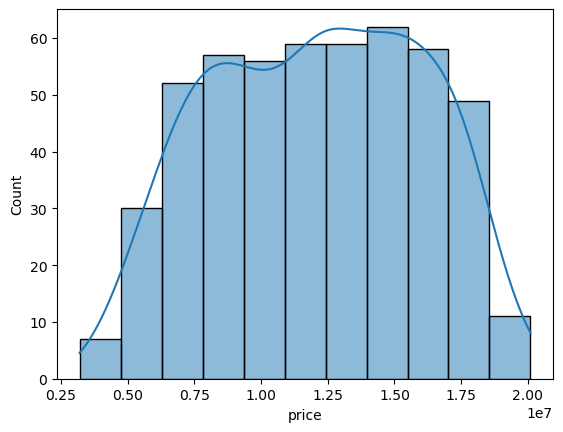

In [24]:
sns.histplot(df['price'], kde=True)
plt.show()

Area vs Price

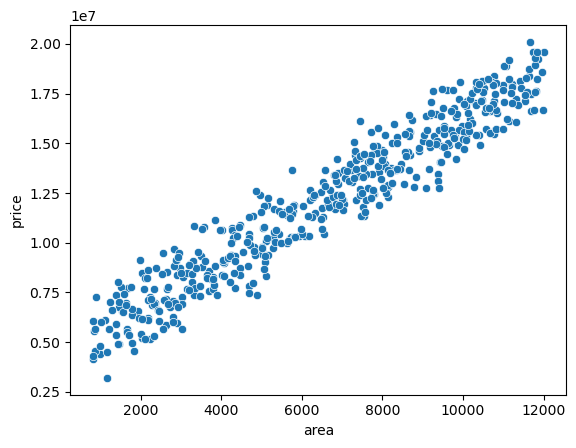

In [25]:
sns.scatterplot(
    x='area',
    y='price',
    data=df
)
plt.show()

Bedrooms Count

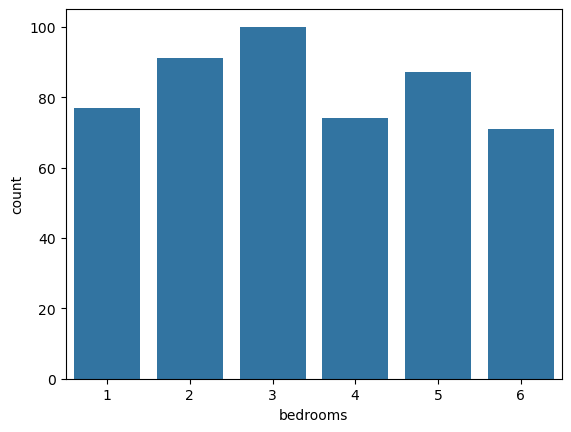

In [26]:
sns.countplot(
    x='bedrooms',
    data=df
)
plt.show()

Convert Categorical Data

In [27]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

Features and Target

In [28]:
X = df.drop('price', axis=1)

y = df['price']

Train Test Split

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Model

In [30]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Prediction

In [31]:
y_pred = model.predict(X_test)

Model Evaluation

In [32]:
from sklearn.metrics import r2_score

r2_score(y_test, y_pred)

0.9771863246271227

Mean Absolute Error

In [33]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(
    y_test,
    y_pred
)

471069.8729

Feature Importance

In [34]:
importance = model.feature_importances_

features = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

features.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
0,area,0.940729
1,bedrooms,0.033038
2,bathrooms,0.010260
8,parking,0.004544
3,stories,0.004259
9,furnishingstatus,0.002698
7,airconditioning,0.001368
5,guestroom,0.001130
6,basement,0.001055
4,mainroad,0.000918


Feature Importance Graph

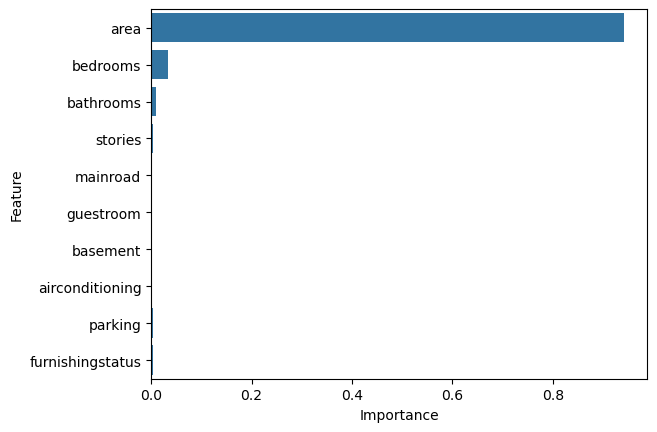

In [35]:
sns.barplot(
    x='Importance',
    y='Feature',
    data=features
)

plt.show()

Predict New House Price

In [36]:
sample = [[7420,4,2,3,2,1,0,1,1,2]]

model.predict(sample)

d:\Anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([12954134.07])